In [1]:
# Data Preprocessing - Using Mean, Median, Mode Imputation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the Data
dataset_path = 'Dataset/dataset.csv'  

print("Loading the dataset...")
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print("\nFirst few rows of the dataset:")
print(df.head())

# 2. Handling Missing and Noisy Values
print("\nChecking for missing values...")
print(df.isnull().sum())

# Replace '?' with NaN in the entire dataset
df = df.replace('?', np.nan)

numerical_columns = df.select_dtypes(include=['number']).columns

# Separate numerical and non-numerical columns
df_numerical = df[numerical_columns].copy()

# Separate the 'target' column before imputation 
if 'target' in df_numerical.columns:
    y_target_original = df['target'].copy()  
    df_numerical = df_numerical.drop('target', axis=1)  
else:
    y_target_original = df['target'].copy() 

def save_preprocessed_data(df_imputed, y_target, method_name):
    df_cleaned = df_imputed.copy()
    # Add back target
    df_cleaned['target'] = y_target
    # Drop rows where target is NaN
    df_cleaned = df_cleaned.dropna(subset=['target'])
    df_cleaned['target'] = df_cleaned['target'].astype(int)

    # Remove Outlier(IQR)
    print(f"\nNumber of rows before outlier removal ({method_name}): {df_cleaned.shape[0]}")
    continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    for col in continuous_features:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) & 
            (df_cleaned[col] <= upper_bound)
        ]
    print(f"Number of rows after IQR-based outlier removal ({method_name}): {df_cleaned.shape[0]}")

    # 3. Normalizing Numerical Features (Min-Max Scaling)
    X_features = df_cleaned.drop('target', axis=1)
    y_target_final = df_cleaned['target']
    X_minmax_scaled = (X_features - X_features.min()) / (X_features.max() - X_features.min())
    X_minmax_scaled = X_minmax_scaled.fillna(0) 

    # Combine normalized features with target
    final_preprocessed_data = X_minmax_scaled.copy()
    final_preprocessed_data['target'] = y_target_final

    print(f"\nPreprocessing completed for {method_name}. Final preprocessed data shape:", final_preprocessed_data.shape)
    print(f"\nFinal preprocessed data (first 5 rows) for {method_name}:")
    print(final_preprocessed_data.head())

    # Save the final dataset
    filename = f'Dataset/dataset_preprocessed_{method_name}.csv'
    final_preprocessed_data.to_csv(filename, index=False)
    print(f"\nPreprocessed data ({method_name}) saved to '{filename}'")


# IMPUTATION USING MEAN 
print("\n" + "="*50)
print("APPLYING MEAN IMPUTATION...")
df_imputed_mean = df_numerical.fillna(df_numerical.mean())
save_preprocessed_data(df_imputed_mean, y_target_original, 'mean')

# IMPUTATION USING MEDIAN 
print("\n" + "="*50)
print("APPLYING MEDIAN IMPUTATION...")
df_imputed_median = df_numerical.fillna(df_numerical.median())
save_preprocessed_data(df_imputed_median, y_target_original, 'median')

# IMPUTATION USING MODE 
print("\n" + "="*50)
print("APPLYING MODE IMPUTATION...")
mode_values = df_numerical.mode().iloc[0] 
df_imputed_mode = df_numerical.fillna(mode_values)
save_preprocessed_data(df_imputed_mode, y_target_original, 'mode')


Loading the dataset...
Dataset loaded successfully.

First few rows of the dataset:
    age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  52.0    1   0     125.0  212.0    0        1    168.0      0      1.0   
1  53.0    1   0     140.0  203.0    1        0    155.0      1      3.1   
2  70.0    1   0     145.0  174.0    0        1    125.0      1      2.6   
3  61.0    1   0     148.0  203.0    0        1    161.0      0      0.0   
4  62.0    0   0     138.0  294.0    1        1    106.0      0      1.9   

   slope   ca  thal  target  
0      2  2.0   3.0       0  
1      0  0.0   3.0       0  
2      0  0.0   3.0       0  
3      2  1.0   3.0       0  
4      1  NaN   NaN       0  

Checking for missing values...
age         51
sex          0
cp           0
trestbps    51
chol        13
fbs          0
restecg      0
thalach     17
exang        0
oldpeak      1
slope        0
ca          51
thal        51
target       0
dtype: int64

APPLYING MEAN IMPUTATIO

Dataset shape: (965, 14)
Continuous features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Train set size: 772
Test set size: 193

→ Results for different K values (3, 5, 7):
   K  Accuracy  Precision  Recall  F1-Score
0  3      0.92       0.88    0.98      0.93
1  5      0.82       0.82    0.87      0.84
2  7      0.84       0.84    0.88      0.86

 Best K value: 3 with accuracy: 0.92


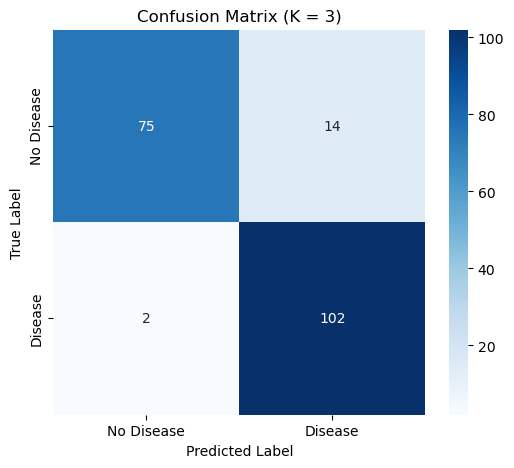

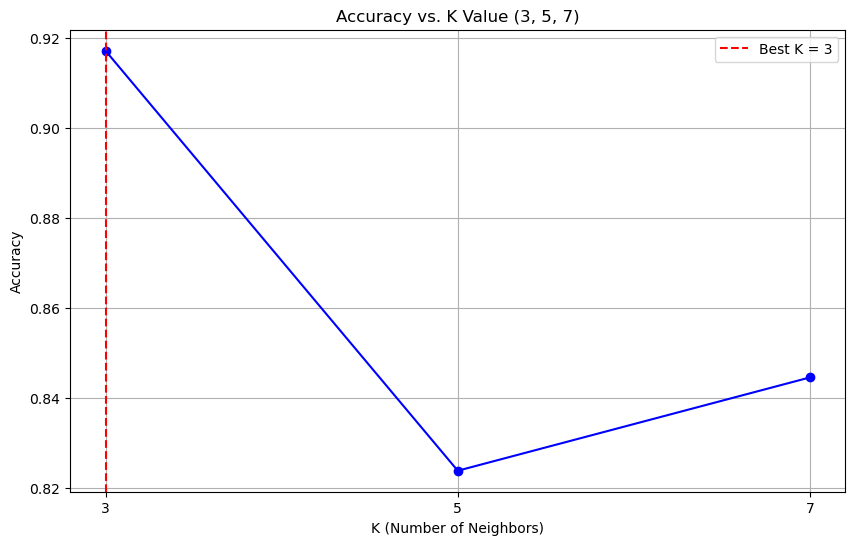


→ Final evaluation metrics (K = 3):
Accuracy: 0.92
Precision: 0.88
Recall: 0.98
F1-Score: 0.93


In [4]:
# Classification using K-Nearest Neighbors (KNN)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#df = pd.read_csv('Dataset/dataset_preprocessed_mean.csv')
#df = pd.read_csv('Dataset/dataset_preprocessed_median.csv')
df = pd.read_csv('Dataset/dataset_preprocessed_mode.csv')

# Separate features (X) and target (y)
X = df.drop('target', axis=1).values  
y = df['target'].values

print(f"Dataset shape: {df.shape}")

# Identify feature indices for continuous and categorical features
feature_names = df.drop('target', axis=1).columns.tolist()
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = [f for f in feature_names if f not in continuous_features]

continuous_indices = [feature_names.index(f) for f in continuous_features]
categorical_indices = [feature_names.index(f) for f in categorical_features]

print(f"Continuous features: {continuous_features}")
print(f"Categorical features: {categorical_features}")

# 1. Split the dataset into 80% training and 20% testing (manually)
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Define manual KNN function with mixed distance
def knn_predict_mixed(X_train, y_train, X_test_instance, k):
    # Euclidean distance for continuous features
    if continuous_indices:
        diff_cont = X_train[:, continuous_indices] - X_test_instance[continuous_indices]
        dist_cont = np.sqrt(np.sum(diff_cont**2, axis=1))
        # Normalize by number of features to balance influence
        dist_cont = dist_cont / len(continuous_indices)
    else:
        dist_cont = 0

    # Hamming distance for categorical features
    if categorical_indices:
        diff_cat = X_train[:, categorical_indices] != X_test_instance[categorical_indices]
        dist_cat = np.sum(diff_cat, axis=1)  # Number of mismatched features
        # Normalize by number of features to balance influence
        dist_cat = dist_cat / len(categorical_indices)
    else:
        dist_cat = 0

    # Combine distances with not equal weights 
    total_distance = 0.60 * dist_cont + 0.40 * dist_cat

    # Find the k nearest neighbors
    k_indices = np.argsort(total_distance)[:k]
    k_labels = y_train[k_indices]
    
    # Majority vote
    prediction = np.bincount(k_labels.astype(int)).argmax()
    
    return prediction

# Define evaluation metrics function (manual)
def calculate_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return accuracy, precision, recall, f1

# 2. Test different K values (3, 5, 7)
k_values = [3, 5, 7]
results = []

for k in k_values:
    y_pred_list = []
    for x_test in X_test:
        pred = knn_predict_mixed(X_train, y_train, x_test, k)
        y_pred_list.append(pred)
    
    y_pred = np.array(y_pred_list)
    
    acc, prec, rec, f1 = calculate_metrics(y_test, y_pred)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)
print("\n→ Results for different K values (3, 5, 7):")
print(results_df.round(2))

# 3. Find the best K
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
best_acc = results_df.loc[results_df['Accuracy'].idxmax(), 'Accuracy']
print(f"\n Best K value: {int(best_k)} with accuracy: {best_acc:.2f}")

# Run the final model with the best K
y_pred_final_list = []
for x_test in X_test:
    pred = knn_predict_mixed(X_train, y_train, x_test, int(best_k))
    y_pred_final_list.append(pred)

y_pred_final = np.array(y_pred_final_list)

# 4. Display Confusion Matrix (manual)
tp = np.sum((y_test == 1) & (y_pred_final == 1))
tn = np.sum((y_test == 0) & (y_pred_final == 0))
fp = np.sum((y_test == 0) & (y_pred_final == 1))
fn = np.sum((y_test == 1) & (y_pred_final == 0))

cm = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix (K = {int(best_k)})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Plot accuracy vs. K
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', linestyle='-', color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K = {int(best_k)}')
plt.title('Accuracy vs. K Value (3, 5, 7)')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

# 6. Display final metrics
final_acc, final_prec, final_rec, final_f1 = calculate_metrics(y_test, y_pred_final)
final_metrics = {
    'Accuracy': final_acc,
    'Precision': final_prec,
    'Recall': final_rec,
    'F1-Score': final_f1
}

print("\n→ Final evaluation metrics (K = {}):".format(int(best_k)))
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.2f}")

→ Generating Overlapping KDEs...


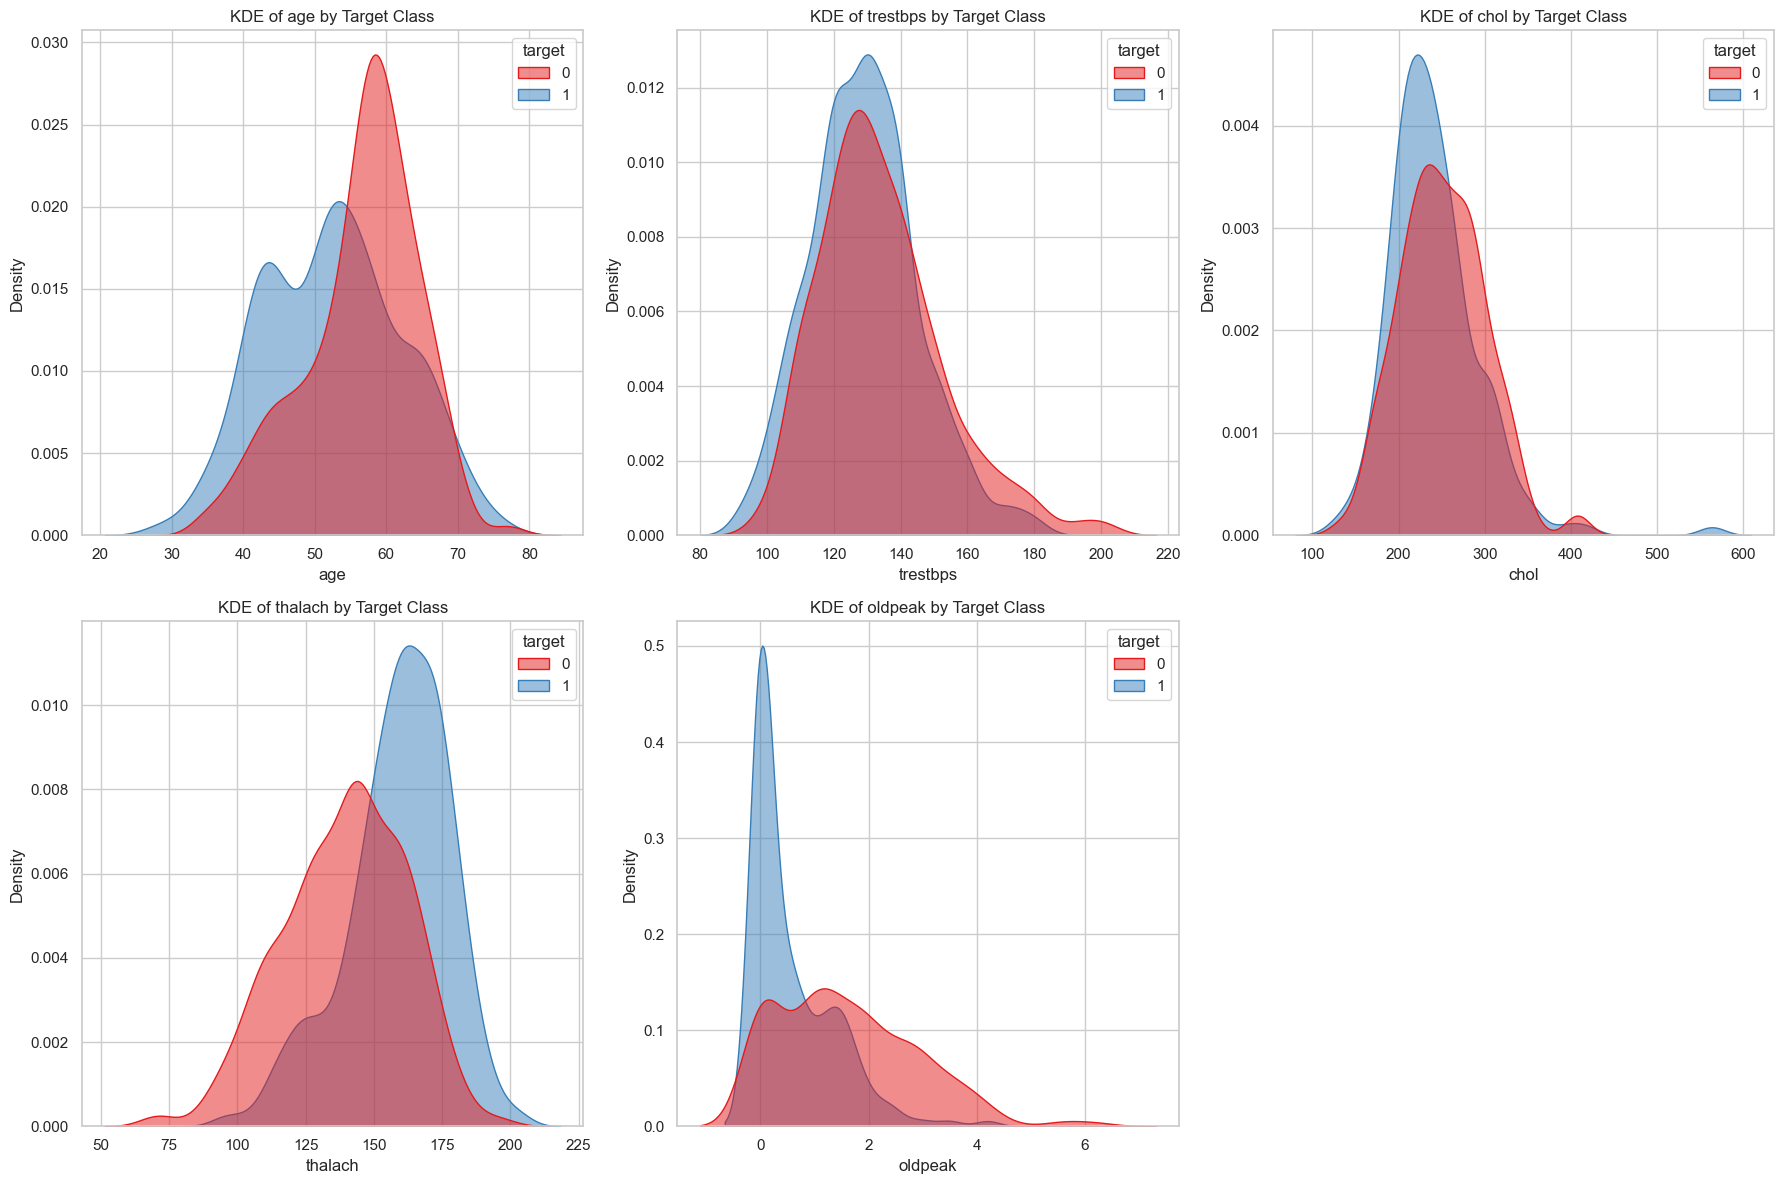

In [5]:
# Exploratory Data Analysis (EDA) - Bonus: KDE Overlap Plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = pd.read_csv('Dataset/dataset.csv')

# Define numerical features
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (18, 12)

# Generate Overlapping KDEs
print("→ Generating Overlapping KDEs...")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_features):
    sns.kdeplot(
        data=df_eda,
        x=col,
        hue='target',
        ax=axes[i],
        fill=True,
        alpha=0.5,
        palette='Set1'
    )
    axes[i].set_title(f'KDE of {col} by Target Class')
    axes[i].set_ylabel('Density')

# Hide the last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()  